<a href="https://colab.research.google.com/github/ChanderValasai/pakistan-tech-pay-gap/blob/main/notebooks/05_visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_PATH = '/content/drive/MyDrive/data-analysis-projects/pakistan-tech-pay-gap'
os.chdir(PROJECT_PATH)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/processed/cleaned_survey_2025.csv')
df['LogComp'] = np.log(df['ConvertedCompYearly'])

sns.set_theme(style='whitegrid', palette='muted')
FIGSIZE = (10, 6)
DPI = 150

Mounted at /content/drive


### Figure 1: Headline Compensation Comparison

**Business purpose:** This is the first chart a reader sees — it needs to communicate the core
finding instantly, before any methodology is explained. Used in the README and at the top of the
full report.

**Chart choice:** A simple bar chart of medians (not means, given the strong right-skew documented
in EDA) is the clearest way to convey one headline number. Anything more complex risks burying the
finding for a first-glance viewer.

**Limitation:** This shows the unadjusted gap only — it does not yet control for experience. That
result is shown separately in Figure 3.

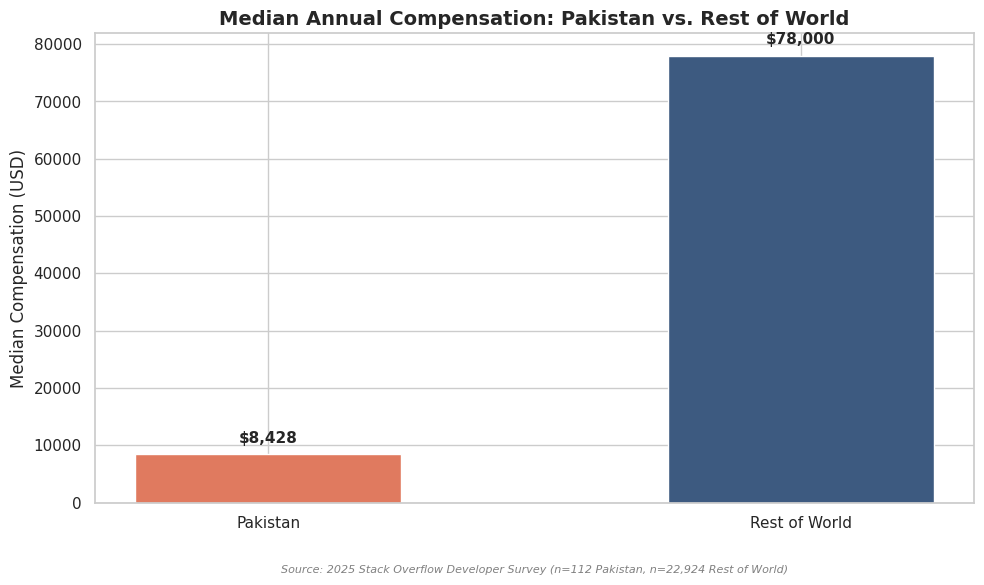

In [3]:
fig, ax = plt.subplots(figsize=FIGSIZE)

order = ['Pakistan', 'Rest of World']
medians = df.groupby('CountryGroup')['ConvertedCompYearly'].median().reindex(order)

bars = ax.bar(order, medians, color=['#e07a5f', '#3d5a80'], width=0.5)
ax.set_title('Median Annual Compensation: Pakistan vs. Rest of World', fontsize=14, fontweight='bold')
ax.set_ylabel('Median Compensation (USD)')
ax.set_xlabel('')

for bar, val in zip(bars, medians):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2000, f'${val:,.0f}',
             ha='center', fontsize=11, fontweight='bold')

ax.text(0.5, -0.15, 'Source: 2025 Stack Overflow Developer Survey (n=112 Pakistan, n=22,924 Rest of World)',
         transform=ax.transAxes, ha='center', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.savefig('figures/01_median_comparison.png', dpi=DPI, bbox_inches='tight')
plt.show()

### Figure 2: Distribution Shape by Group

**Business purpose:** Justifies our methodological choice to use median (not mean) and log-scale
statistical tests. This is a supporting chart for the technical report — it explains a decision,
rather than delivering a headline finding.

**Chart choice:** A KDE (smoothed density) plot makes the right-skew and separation between groups
visually obvious, without the bin-width sensitivity a histogram would introduce.

**Limitation:** Clipped at $300k for readability. Extreme high-end values exist beyond this range
and are addressed separately in the data cleaning documentation — this chart is not showing the
full tail.

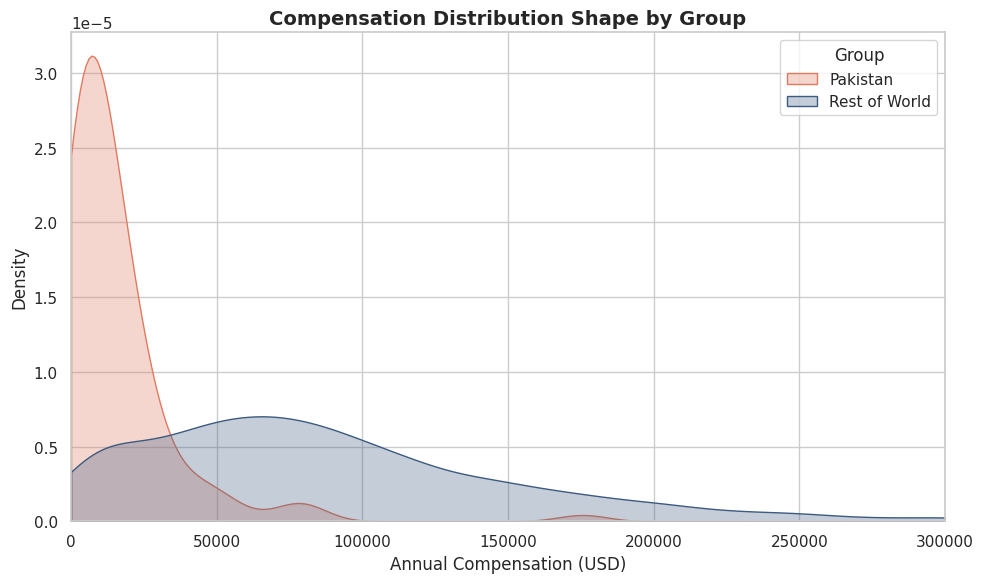

In [4]:
fig, ax = plt.subplots(figsize=FIGSIZE)

for group, color in zip(['Pakistan', 'Rest of World'], ['#e07a5f', '#3d5a80']):
    subset = df[df['CountryGroup'] == group]['ConvertedCompYearly']
    sns.kdeplot(subset, label=group, fill=True, alpha=0.3, color=color, ax=ax, clip=(0, 300000))

ax.set_title('Compensation Distribution Shape by Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Compensation (USD)')
ax.set_ylabel('Density')
ax.legend(title='Group')
ax.set_xlim(0, 300000)

plt.tight_layout()
plt.savefig('figures/02_distribution_shape.png', dpi=DPI, bbox_inches='tight')
plt.show()

### Figure 3: Compensation Gap Persists Across Experience Levels

**Business purpose:** The most important chart in this project — it visually demonstrates that the
gap is not simply an artifact of Pakistan's respondents being less experienced. Belongs in both
the README and the full report, directly after the headline number.

**Chart choice:** A grouped bar chart repeats the same comparison across experience bands, which is
the most intuitive way to show "this holds at every level" to a non-technical viewer.

**Limitation:** The 15–25 and 25+ year bands have very small Pakistan samples (n=7 and n=5) — noted
directly on the chart itself, not hidden in a caption elsewhere, so the limitation travels with the
image wherever it's used.

**Improvement idea:** Adding confidence intervals or error bars per band would strengthen this
further once a larger sample is available.

In [6]:
bins = [0, 5, 10, 15, 25, 100]
labels = ['0-5', '5-10', '10-15', '15-25', '25+']
df['ExpBand'] = pd.cut(df['YearsCode'], bins=bins, labels=labels, include_lowest=True)

/tmp/ipykernel_1074/4187467302.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  strat = df.groupby(['ExpBand', 'CountryGroup'])['ConvertedCompYearly'].median().unstack()


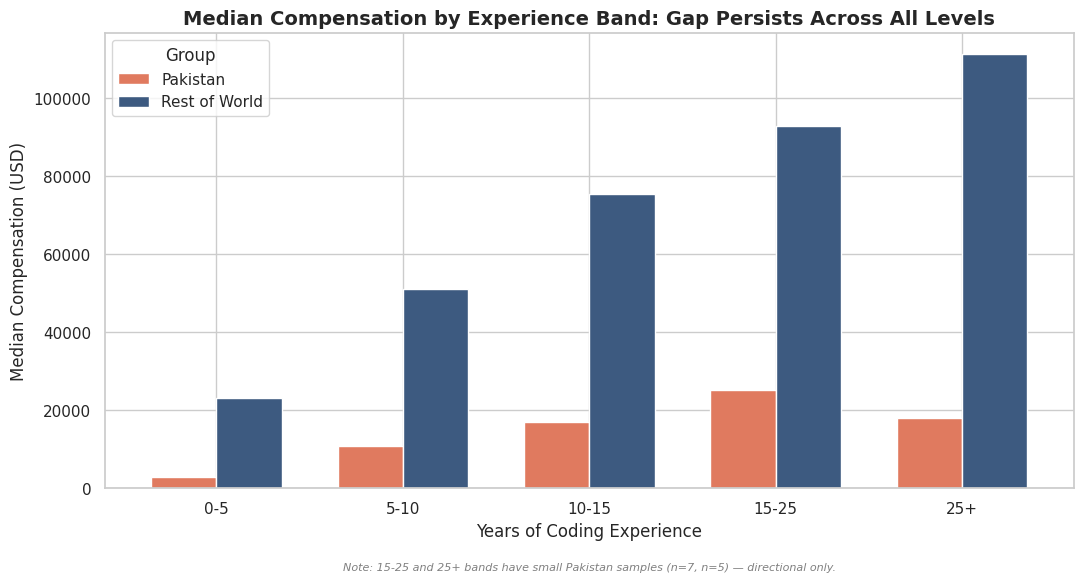

In [7]:
strat = df.groupby(['ExpBand', 'CountryGroup'])['ConvertedCompYearly'].median().unstack()

fig, ax = plt.subplots(figsize=(11, 6))
strat.plot(kind='bar', ax=ax, color=['#e07a5f', '#3d5a80'], width=0.7)

ax.set_title('Median Compensation by Experience Band: Gap Persists Across All Levels',
              fontsize=14, fontweight='bold')
ax.set_xlabel('Years of Coding Experience')
ax.set_ylabel('Median Compensation (USD)')
ax.legend(title='Group')
plt.xticks(rotation=0)

ax.text(0.5, -0.18,
        'Note: 15-25 and 25+ bands have small Pakistan samples (n=7, n=5) — directional only.',
        transform=ax.transAxes, ha='center', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.savefig('figures/03_gap_by_experience.png', dpi=DPI, bbox_inches='tight')
plt.show()